<a href="https://colab.research.google.com/github/FurqanAlyy/AI-ML-NIAI/blob/main/svm_student_v3_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 SVM Student Lab — Updated to Match the Lecture 17 Slides
### Build your intuition — step by step, starting with the salary data you already know

---

### 📌 What You Will Practise

| Concept | What it means in plain English | Slide |
|---|---|---|
| **Hyperplane & score** | The dividing line, written as `score = weight × column + … + constant` | Hyperplane, The Rule |
| **Margin** | The width of the empty street between the two groups | Anatomy of an SVM |
| **Support vectors** | The few dots touching the street edge — they alone decide where the street goes | Support Vectors |
| **Hard vs soft margin, C** | "No mistakes allowed" vs "a few mistakes are fine" — C is the strictness dial | Hard Margin, Soft Margin |
| **Kernels** | Linear, polynomial, radial (RBF): how the boundary is allowed to bend | Three Kernels |
| **gamma** | How far each dot's influence reaches in the RBF kernel | The RBF Dial Called Gamma |

### 🌍 Datasets We Use
| Dataset | What it is | Problem |
|---|---|---|
| **Salary data** | The same 20 people from the lecture (experience, education, age, certifications, salary) | Is this person a **High earner** (salary ≥ $55k)? |
| **Breast Cancer** | 569 patients, 30 medical measurements | Is the tumour malignant or benign? |
| **Iris Flowers** *(bonus)* | 150 flowers, 4 measurements | Which of 3 species is this flower? |

### 🗺️ The Plan
| Part | Tasks | Focus |
|---|---|---|
| **Part 1 — Salary data** | Tasks 1–5 | The same ideas as the slides, on 20 people you can check by hand |
| **Part 2 — Breast Cancer** | Tasks 6–8 (+ Task 9 bonus) | Do the same ideas hold on real medical data? |
| **Part 3 — Iris** | Task 10 (bonus) | Compare kernels on a 3-class problem |

**Core work = Tasks 1–8.** The two ⭐ bonus tasks are for fast finishers.

### 📋 How to work through this
- Read each **Background** section carefully — the concept is explained there
- Then do the numbered steps in the code cell
- **💬 Think About It** boxes have questions — write your answers in your notes or a markdown cell
- Hidden solutions are available if you are stuck — but try first!

---

In [1]:
# ╔═══════════════════════════════════════╗
# ║  RUN THIS CELL FIRST — every time!   ║
# ╚═══════════════════════════════════════╝
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ── The salary table from the lecture (20 people) ───────────────────────────
salary_columns = ['experience', 'education', 'age', 'certifications', 'salary']
salary_rows = [      # experience, education, age, certifications, salary ($k)
    (1,16,23,0,35), (2,16,24,1,40), (3,18,26,1,47), (4,16,27,2,51),
    (5,18,29,2,58), (6,18,31,3,62), (7,20,33,3,70), (8,20,35,4,75),   # rows 1-8: the original regression table
    (1,18,24,1,42), (2,20,26,2,52), (3,16,25,0,41), (4,20,28,3,60),
    (5,16,30,1,53), (6,16,32,1,56), (7,18,31,2,66), (8,16,36,2,64),
    (9,20,34,4,82), (10,18,38,3,80), (2,16,22,0,36), (9,16,40,1,68),  # rows 9-20: added for classification
]
HI, LO = '#2E8B57', '#B23A48'      # green square = High earner, red circle = Not high

# ── Real datasets ───────────────────────────────────────────────────────────
cancer = datasets.load_breast_cancer()
iris   = datasets.load_iris()

print('✅ Ready to go!')
print(f'  Salary table  : {len(salary_rows)} people, columns = {salary_columns}')
print(f'  Breast Cancer : {cancer.data.shape}')
print(f'  Iris          : {iris.data.shape}')

✅ Ready to go!
  Salary table  : 20 people, columns = ['experience', 'education', 'age', 'certifications', 'salary']
  Breast Cancer : (569, 30)
  Iris          : (150, 4)


---
---
# 💼 PART 1 — The Salary Data
## "Is this person a High earner?"

You already know these 20 people from the regression lectures. Now the question changes from *"how much?"* to *"which group?"*.  
Because there are only 20 dots and 2 columns, you can **check every number by hand** — perfect for understanding what SVM really does.

---

---
## ✏️ Task 1 — Look Before You Train: The Salary Data

### Background
Every classification problem starts with a **label** — the "right answer" the computer learns from.  
Here the label is: **High earner = salary of $55k or more**.

To draw the data on paper we use just **two columns**: `experience` (x-axis) and `certifications` (y-axis).  
Each dot is one person. We use the same colours as the slides: **green square** = High earner, **red circle** = Not high.

### Steps
1. Build a DataFrame `df` from `salary_rows` with the column names in `salary_columns`
2. Add a column `high_earner` that is `1` when salary ≥ 55 and `0` otherwise
3. Print how many High earners and how many Not high there are
4. Create `X` (the two columns `experience` and `certifications`, as a NumPy array) and `y` (the `high_earner` column)
5. Make a scatter plot of the 20 people with the slide colours and a legend
6. Look at your plot: where would you draw a straight line to separate the two groups?

> 💡 `df["salary"] >= 55` gives True/False; `.astype(int)` turns it into 1/0  
> 💡 `ax.scatter(x, y, marker="s")` draws squares, `marker="o"` draws circles

High earners : 11
Not high     : 9


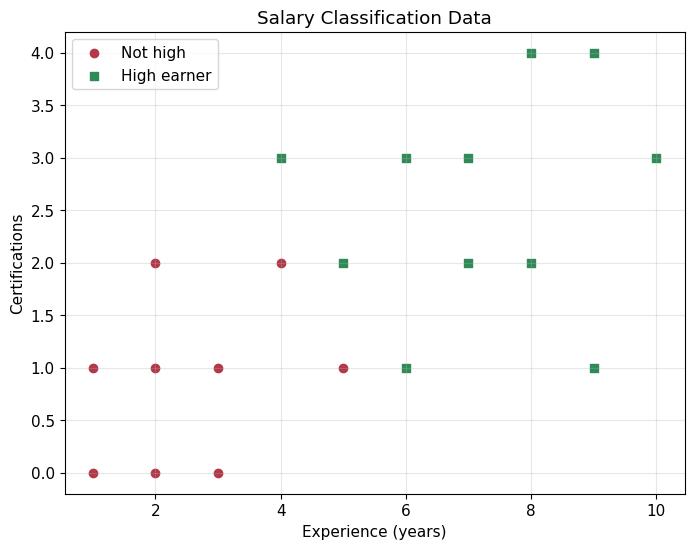

In [2]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 1: Look Before You Train ─────────────────────────────────────────

# 1. Build the DataFrame
df = pd.DataFrame(salary_rows, columns=salary_columns)

# 2. Create the target column
df['high_earner'] = (df['salary'] >= 55).astype(int)

# 3. Count High earners and Not high earners
print("High earners :", (df['high_earner'] == 1).sum())
print("Not high     :", (df['high_earner'] == 0).sum())

# 4. Create X and y
X = df[['experience', 'certifications']].values
y = df['high_earner'].values

# 5. Plot the data
fig, ax = plt.subplots(figsize=(8, 6))

# Not high earners
ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    c=LO,
    marker='o',
    label='Not high'
)

# High earners
ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    c=HI,
    marker='s',
    label='High earner'
)

ax.set_xlabel('Experience (years)')
ax.set_ylabel('Certifications')
ax.set_title('Salary Classification Data')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

**💬 Think About It:**

*Are the two groups roughly balanced?*  
*Where do the green squares sit compared with the red circles?*  
*Could one straight line separate them perfectly? Roughly where would it go?*

<details><summary>💡 Reveal Solution</summary>

```python
df = pd.DataFrame(salary_rows, columns=salary_columns)
df.index = df.index + 1                      # person numbers 1..20
df.index.name = 'person'
df['high_earner'] = (df['salary'] >= 55).astype(int)
display(df)
print('High earners:', df['high_earner'].sum(), '| Not high:', (df['high_earner'] == 0).sum())

X = df[['experience', 'certifications']].values     # the two columns we draw
y = df['high_earner'].values                         # 1 = High earner, 0 = Not high

fig, ax = plt.subplots(figsize=(8, 5))
hi = (y == 1)
ax.scatter(X[hi, 0],  X[hi, 1],  marker='s', s=120, c=HI, edgecolors='white', label='High earner (≥ $55k)')
ax.scatter(X[~hi, 0], X[~hi, 1], marker='o', s=120, c=LO, edgecolors='white', label='Not high')
for person, (a, b) in zip(df.index, X):
    ax.text(a + 0.12, b + 0.12, str(person), fontsize=8, color='#555')
ax.set_xlabel('Experience (years)'); ax.set_ylabel('Certifications')
ax.set_title('The salary data with a Yes/No label', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 2 — Find the Hyperplane, the Margin and the Support Vectors

### Background
On the slides, SVM found this rule for our data:

```
score = 2 × experience + 2 × certifications − 13
```

- **Hyperplane** = where the score is exactly **0** (for 2 columns this is a line)
- **Margin edges** = where the score is **+1** and **−1**; the **margin** is the width of the street between them: `2 ÷ √(w₁² + w₂²)`
- **Support vectors** = the dots that sit on a margin edge (score = ±1)
- **Hard margin** = no mistakes allowed. In scikit-learn we get it by using a *very large* C, such as `1_000_000`

Now you will make the computer find these numbers itself and check them against the slides.

> ⚠️ In this task we do **not** scale the data, so the weights stay readable (the slides did the same).

### Steps
1. Using `X` and `y` from Task 1, train `SVC(kernel="linear", C=1_000_000)`
2. Print the **weights** (`clf.coef_`) and the **constant** (`clf.intercept_`). Do they match 2, 2 and −13?
3. Compute the **margin width** = `2 / np.linalg.norm(clf.coef_[0])`
4. Use `clf.decision_function(X)` to get every person's score. Print the persons whose score is exactly +1 or −1 (use `np.abs(np.abs(scores) - 1) < 1e-3`)
5. Print `clf.support_` (the support vectors scikit-learn reports). Compare with your list from step 4
6. Classify the **tricky person** (3 years of experience, 4 certifications): print their score and the predicted group
7. Plot the data, the hyperplane (solid line), the two margin edges (dashed) and circle the dots on the edges

> 💡 `clf.coef_[0]` → the two weights  |  `clf.intercept_[0]` → the constant  
> 💡 To draw the line for score = `off`: `y = (-(w[0]*x + b) + off) / w[1]`

Weights  : [2. 2.]
Constant : -13.000000000000036
Margin width : 0.707106781186544

People on margin:
Person 4: score = -1.000, class = 0
Person 5: score = 1.000, class = 1
Person 12: score = 1.000, class = 1
Person 13: score = -1.000, class = 0
Person 14: score = 1.000, class = 1

Support vector indices : [ 3 12  4]
Support vector persons : [ 4 13  5]

Tricky person [3 years, 4 certifications]
Score      : 1.0
Prediction : High earner


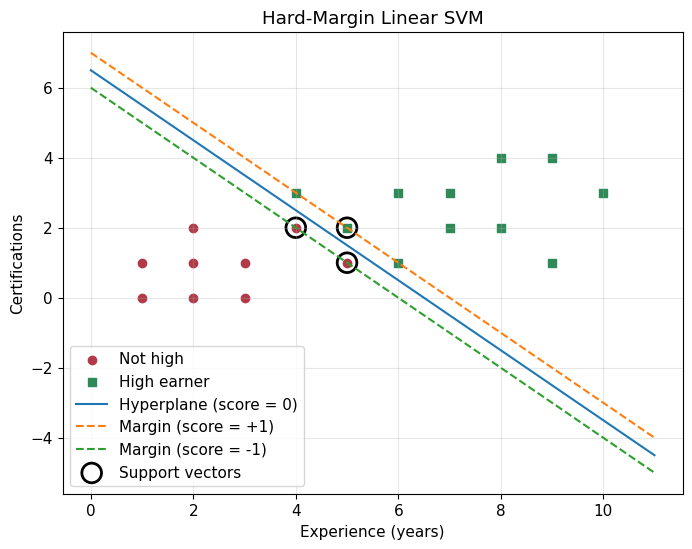

In [3]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 2: Hyperplane, Margin and Support Vectors ─────────────────────────

# 1. Train a hard-margin Linear SVM
clf = SVC(kernel='linear', C=1_000_000)
clf.fit(X, y)

# 2. Print weights and constant
w = clf.coef_[0]
b = clf.intercept_[0]

print("Weights  :", w)
print("Constant :", b)

# 3. Calculate margin width
margin_width = 2 / np.linalg.norm(w)
print("Margin width :", margin_width)

# 4. Calculate decision scores for all people
scores = clf.decision_function(X)

# Find people whose score is approximately +1 or -1
on_margin = np.where(np.abs(np.abs(scores) - 1) < 1e-3)[0]

print("\nPeople on margin:")
for i in on_margin:
    print(
        f"Person {i + 1}: "
        f"score = {scores[i]:.3f}, "
        f"class = {y[i]}"
    )

# 5. Support vectors reported by sklearn
print("\nSupport vector indices :", clf.support_)
print("Support vector persons :", clf.support_ + 1)

# 6. Classify tricky person
tricky = np.array([[3, 4]])

tricky_score = clf.decision_function(tricky)[0]
tricky_prediction = clf.predict(tricky)[0]

print("\nTricky person [3 years, 4 certifications]")
print("Score      :", round(tricky_score, 3))
print(
    "Prediction :",
    "High earner" if tricky_prediction == 1 else "Not high"
)

# 7. Plot data, hyperplane and margin edges
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Not high earners
ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    c=LO,
    marker='o',
    label='Not high'
)

# Plot High earners
ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    c=HI,
    marker='s',
    label='High earner'
)

# x-values for drawing the lines
x_vals = np.linspace(X[:, 0].min() - 1,
                     X[:, 0].max() + 1,
                     200)

# Hyperplane: score = 0
y_hyperplane = (-(w[0] * x_vals + b)) / w[1]

# Margin: score = +1
y_margin_positive = (-(w[0] * x_vals + b) + 1) / w[1]

# Margin: score = -1
y_margin_negative = (-(w[0] * x_vals + b) - 1) / w[1]

ax.plot(
    x_vals,
    y_hyperplane,
    '-',
    label='Hyperplane (score = 0)'
)

ax.plot(
    x_vals,
    y_margin_positive,
    '--',
    label='Margin (score = +1)'
)

ax.plot(
    x_vals,
    y_margin_negative,
    '--',
    label='Margin (score = -1)'
)

# Circle support vectors
ax.scatter(
    X[clf.support_, 0],
    X[clf.support_, 1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support vectors'
)

ax.set_xlabel('Experience (years)')
ax.set_ylabel('Certifications')
ax.set_title('Hard-Margin Linear SVM')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

**💬 Think About It:**

*Do the weights and constant match the slide rule?*  
*How wide is the street?*  
*How many dots sit exactly on a street edge? Does scikit-learn list all of them as support vectors? (Look carefully at the two lists.)*  
*What does a score of +1 for the tricky person tell you about where they stand?*

<details><summary>💡 Reveal Solution</summary>

```python
clf = SVC(kernel='linear', C=1_000_000).fit(X, y)       # very large C = hard margin
w = clf.coef_[0]; b = clf.intercept_[0]
print(f'score = {w[0]:.2f} × experience + {w[1]:.2f} × certifications {b:+.2f}')

width = 2 / np.linalg.norm(w)
print(f'Margin width = 2 / ‖w‖ = {width:.2f}')

scores = clf.decision_function(X)
edge = np.where(np.abs(np.abs(scores) - 1) < 1e-3)[0]
print('Persons exactly on a street edge (|score| = 1):', [int(i) + 1 for i in edge])
print('Persons listed by scikit-learn as support vectors :', sorted(int(i) + 1 for i in clf.support_))
print('(Two edge dots tie exactly with the others, so scikit-learn does not need them to define the street.)')

tricky = [[3, 4]]
print(f'\nTricky person: score = {clf.decision_function(tricky)[0]:+.2f}  ->',
      'High earner' if clf.predict(tricky)[0] == 1 else 'Not high')

xs = np.linspace(0, 11, 100)
line = lambda off: (-(w[0] * xs + b) + off) / w[1]
fig, ax = plt.subplots(figsize=(9, 5.5))
hi = (y == 1)
ax.fill_between(xs, line(-1), line(1), color='#C98A2C', alpha=0.15)
ax.plot(xs, line(0), 'k-', lw=2.5, label='Hyperplane (score = 0)')
ax.plot(xs, line(1), '--', color='#C98A2C', lw=1.6, label='Margin edges (score = ±1)')
ax.plot(xs, line(-1), '--', color='#C98A2C', lw=1.6)
ax.scatter(X[hi, 0],  X[hi, 1],  marker='s', s=110, c=HI, edgecolors='white', zorder=3)
ax.scatter(X[~hi, 0], X[~hi, 1], marker='o', s=110, c=LO, edgecolors='white', zorder=3)
ax.scatter(X[edge, 0], X[edge, 1], s=380, facecolors='none', edgecolors='navy', lw=2.2, zorder=4, label='Dots on the edge')
ax.scatter(*tricky[0], marker='*', s=350, c='gold', edgecolors='navy', zorder=5, label='Tricky person')
ax.set_xlim(0, 11); ax.set_ylim(-0.7, 5)
ax.set_xlabel('Experience (years)'); ax.set_ylabel('Certifications')
ax.set_title('Hyperplane, margin and support vectors on the salary data', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 3 — Hard Margin Breaks, Soft Margin Saves the Day (the C Dial)

### Background
A **hard margin** works only if one straight line can separate the groups *perfectly*. Our 20 people can be separated — but real data has odd people.

Meet the **odd person**: **8 years of experience, 0 certifications, Not high** (invented for teaching; not in the table).  
Add them and **no straight line gets everyone right**. A hard margin has no answer.

The fix is the **soft margin**, controlled by the dial **C**:

| | Small C | Large C |
|---|---|---|
| Attitude | "A few mistakes are fine" | "Never tolerate a mistake" |
| Street | **Wide** | **Thin** |
| Risk | Too simple (underfitting) | Tilts to please one odd dot (overfitting) |

### Steps
1. Make `X_odd` and `y_odd`: add the odd person (8, 0) with label `0` to `X` and `y` (21 people)
2. For each `C` in `[0.01, 0.1, 1, 10, 1000, 1_000_000]` train a **linear** SVC on the 21 people and record: training accuracy, number of support vectors, margin width
3. Print a neat table of the results
4. Do the **same table for the original 20 people** (no odd person) and compare the two tables
5. As C grows, what happens to the margin width and to the number of support vectors?
6. With the odd person, can the training accuracy ever reach 100%, even at `C = 1_000_000`?

> 💡 `np.vstack([X, [8, 0]])` adds a row; `np.append(y, 0)` adds a label  
> 💡 `clf.score(X, y)` → training accuracy  |  `len(clf.support_)` → number of support vectors

In [4]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 3: Hard Margin vs Soft Margin — The C Dial ────────────────────────

# 1. Add the odd person: 8 years experience, 0 certifications, Not high
X_odd = np.vstack([X, [8, 0]])
y_odd = np.append(y, 0)

C_values = [0.01, 0.1, 1, 10, 1000, 1_000_000]


# Helper function to test different C values
def test_c_values(X_data, y_data):
    results = []

    for C in C_values:
        clf_c = SVC(kernel='linear', C=C)
        clf_c.fit(X_data, y_data)

        # Training accuracy
        accuracy = clf_c.score(X_data, y_data)

        # Number of support vectors
        n_support = len(clf_c.support_)

        # Margin width = 2 / ||w||
        w = clf_c.coef_[0]
        margin_width = 2 / np.linalg.norm(w)

        results.append({
            'C': C,
            'Training Accuracy': accuracy,
            'Support Vectors': n_support,
            'Margin Width': margin_width
        })

    return pd.DataFrame(results)


# 2 & 3. Test dataset WITH odd person
results_odd = test_c_values(X_odd, y_odd)

print("WITH ODD PERSON (21 people)")
print(results_odd.to_string(index=False))


# 4. Test original dataset WITHOUT odd person
results_original = test_c_values(X, y)

print("\nORIGINAL DATA (20 people)")
print(results_original.to_string(index=False))

WITH ODD PERSON (21 people)
         C  Training Accuracy  Support Vectors  Margin Width
      0.01           0.904762               18      7.615678
      0.10           0.952381               10      3.536842
      1.00           0.952381                7      1.485741
     10.00           0.952381                4      0.707107
   1000.00           0.952381                4      0.447369
1000000.00           0.952381                4      0.447388

ORIGINAL DATA (20 people)
         C  Training Accuracy  Support Vectors  Margin Width
      0.01               0.95               16      7.527099
      0.10               0.95                8      4.000000
      1.00               0.90                5      1.414214
     10.00               1.00                3      0.707107
   1000.00               1.00                3      0.707107
1000000.00               1.00                3      0.707107


**💬 Think About It:**

*Why can the 21-person data never reach 100% training accuracy, even with the largest C?*  
*What happens to the street width as C gets larger? To the number of support vectors?*  
*On the original 20 people, `C = 1` does not reach 100% but `C = 10` does. Why would a soft margin choose a wider street over a perfect score?*  
*Which C would you pick for new, unseen people, and why?*

<details><summary>💡 Reveal Solution</summary>

```python
X_odd = np.vstack([X, [8, 0]])
y_odd = np.append(y, 0)
print('21 people = original 20 + odd person (8 yrs, 0 certs, Not high)\n')

def c_table(Xd, yd, title):
    print(title)
    print(f'{"C":>10}  {"Train acc":>9}  {"#SVs":>5}  {"Street width":>12}')
    print('-' * 44)
    widths = []
    for C in [0.01, 0.1, 1, 10, 1000, 1_000_000]:
        m = SVC(kernel='linear', C=C).fit(Xd, yd)
        wd = 2 / np.linalg.norm(m.coef_[0])
        widths.append(wd)
        print(f'{C:>10g}  {m.score(Xd, yd):>9.3f}  {len(m.support_):>5}  {wd:>12.2f}')
    print()
    return widths

w_odd   = c_table(X_odd, y_odd, 'WITH the odd person (21 people):')
w_clean = c_table(X, y,         'ORIGINAL 20 people:')

Cs = [0.01, 0.1, 1, 10, 1000, 1_000_000]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(Cs, w_clean, 'o-', color=HI, label='20 people')
ax.semilogx(Cs, w_odd, 's-', color=LO, label='21 people (with odd person)')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Street width')
ax.set_title('Larger C  →  thinner street', fontweight='bold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 4 — Three Kernels on the Salary Data

### Background
A **kernel** decides how the boundary is allowed to bend:

| Kernel | Plain-words idea | Boundary |
|---|---|---|
| **Linear** | A straight cut. No extra columns | Straight line |
| **Polynomial** | Adds columns made by multiplying columns together | Smooth curves |
| **Radial (RBF)** | Every dot spreads a bubble of influence that fades with distance | Almost any shape |

How do we compare models fairly? A model that memorises the training data scores 100% *on that data* — which proves nothing.  
So we use a **left-out score**: remove one person, train on the other 19, test on the removed person, repeat for all 20, and average.  
In scikit-learn this is `cross_val_score(pipe, X, y, cv=LeaveOneOut())`.

⚠️ Kernels use distances, so **scale first**. `make_pipeline(StandardScaler(), SVC(...))` does that every time.

### Steps
1. Build three SVC settings: `kernel="linear"`, `kernel="poly", degree=3, coef0=1`, `kernel="rbf", gamma="scale"`
2. For `C = 1` **and** `C = 10`, for each kernel: build `make_pipeline(StandardScaler(), SVC(...))`
3. Record the **training score** (fit on all 20, score on all 20) and the **left-out score** (`LeaveOneOut`)
4. Also print what each model says about the **tricky person** (3 years, 4 certifications)
5. Print a table: kernel × C → training score, left-out score, tricky person
6. Which kernel wins at `C = 1`? Which wins at `C = 10`?

> 💡 `cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()` → the left-out score  
> 💡 `pipe.predict([[3, 4]])` → answer for one new person (1 = High earner)

In [5]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 4: Three Kernels on the Salary Data ───────────────────────────────

# 1. Define the three kernel settings
kernels = {
    'Linear': {
        'kernel': 'linear'
    },
    'Polynomial': {
        'kernel': 'poly',
        'degree': 3,
        'coef0': 1
    },
    'RBF': {
        'kernel': 'rbf',
        'gamma': 'scale'
    }
}

C_values = [1, 10]

# Tricky person
tricky_person = [[3, 4]]

results = []

# 2. Try C = 1 and C = 10
for C in C_values:

    for kernel_name, params in kernels.items():

        # Create pipeline:
        # StandardScaler -> SVM
        pipe = make_pipeline(
            StandardScaler(),
            SVC(C=C, **params)
        )

        # 3. Fit on all 20 people
        pipe.fit(X, y)

        # Training score
        training_score = pipe.score(X, y)

        # Leave-One-Out cross-validation score
        loo_score = cross_val_score(
            pipe,
            X,
            y,
            cv=LeaveOneOut()
        ).mean()

        # 4. Prediction for tricky person
        tricky_prediction = pipe.predict(tricky_person)[0]

        tricky_answer = (
            'High earner'
            if tricky_prediction == 1
            else 'Not high'
        )

        # Store results
        results.append({
            'Kernel': kernel_name,
            'C': C,
            'Training Score': training_score,
            'Left-Out Score': loo_score,
            'Tricky Person': tricky_answer
        })


# 5. Create and print results table
results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

    Kernel  C  Training Score  Left-Out Score Tricky Person
    Linear  1            0.95            0.85   High earner
Polynomial  1            0.90            0.85   High earner
       RBF  1            1.00            0.85   High earner
    Linear 10            1.00            1.00   High earner
Polynomial 10            1.00            0.95   High earner
       RBF 10            1.00            0.80   High earner


**💬 Think About It:**

*At C = 1, do the kernels differ in left-out score? At C = 10?*  
*RBF reaches 100% training score. Does that make it the best model? What does the left-out score say?*  
*Our data can already be cut by a straight line. Why might the simplest kernel win?*  
*With only 20 people, how many percentage points is one person worth?*

<details><summary>💡 Reveal Solution</summary>

```python
kernels = {
    'linear':          dict(kernel='linear'),
    'poly (degree 3)': dict(kernel='poly', degree=3, coef0=1),
    'rbf':             dict(kernel='rbf', gamma='scale'),
}
print(f'{"Kernel":<16}{"C":>4}  {"Training":>9}  {"Left-out":>9}  Tricky person')
print('-' * 56)
for C in (1, 10):
    for name, kw in kernels.items():
        pipe = make_pipeline(StandardScaler(), SVC(C=C, **kw))
        left_out = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()
        pipe.fit(X, y)
        train = pipe.score(X, y)
        tricky_ans = 'High' if pipe.predict([[3, 4]])[0] == 1 else 'Not high'
        print(f'{name:<16}{C:>4}  {train:>9.2f}  {left_out:>9.2f}  {tricky_ans}')
    print()
print('One person = 5 points with only 20 people, so treat small gaps with care.')
```
</details>

---
## ✏️ Task 5 — The RBF Dial Called Gamma

### Background
**gamma** controls how far each dot's influence reaches in the RBF kernel:

```
SMALL gamma                         LARGE gamma
Huge bubbles                        Tiny bubbles
Smooth, too-simple boundary         An island around nearly every dot
UNDERFITTING                        OVERFITTING (memorising)
```

This is the same danger you met with **K = 1 in KNN**: a model that copies every dot exactly looks perfect on old data and fails on new data.

### Steps
1. For `gamma` in `[0.01, 0.1, 1, 10, 50]`, build `make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=gamma))`
2. Record the **training score** and the **left-out score** (`LeaveOneOut`) for each gamma
3. Print a table and make a line plot: training score (red) and left-out score (blue) against gamma on a log x-axis
4. Which gamma memorises the 20 people? Which gamma gives the best left-out score?
5. What does the tricky person get at each gamma?

> 💡 `np.argmax(list)` gives the position of the largest value  
> 💡 `ax.semilogx(x, y)` draws a line with a log-scale x-axis

 Gamma  Training Score  Left-Out Score Tricky Person
  0.01            0.80            0.55   High earner
  0.10            0.95            0.95   High earner
  1.00            1.00            0.80   High earner
 10.00            1.00            0.65   High earner
 50.00            1.00            0.55   High earner


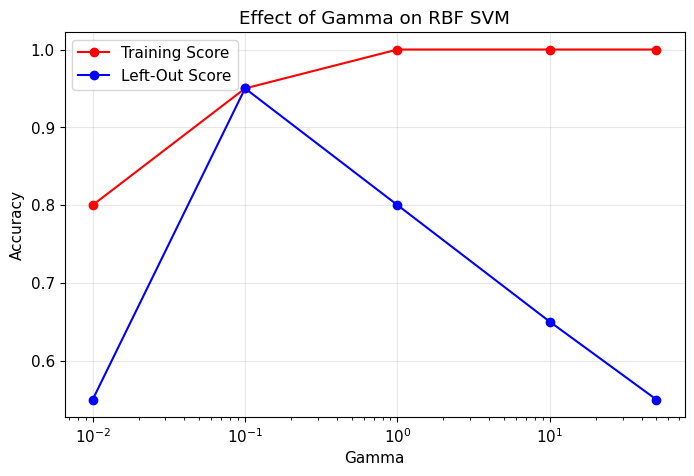


Gamma(s) with highest training score: [1, 10, 50]
Highest training score: 1.0

Best gamma based on Left-Out Score: 0.1
Best Left-Out Score: 0.95


In [6]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 5: The RBF Dial Called Gamma ─────────────────────────────────────

gamma_values = [0.01, 0.1, 1, 10, 50]

training_scores = []
loo_scores = []
tricky_predictions = []

tricky_person = [[3, 4]]

# 1. Try each gamma value
for gamma in gamma_values:

    # Build pipeline: scaling + RBF SVM
    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1, gamma=gamma)
    )

    # Train on all 20 people
    pipe.fit(X, y)

    # 2. Training score
    train_score = pipe.score(X, y)

    # Leave-One-Out score
    loo_score = cross_val_score(
        pipe,
        X,
        y,
        cv=LeaveOneOut()
    ).mean()

    # 5. Prediction for tricky person
    tricky_pred = pipe.predict(tricky_person)[0]

    tricky_answer = (
        'High earner'
        if tricky_pred == 1
        else 'Not high'
    )

    training_scores.append(train_score)
    loo_scores.append(loo_score)
    tricky_predictions.append(tricky_answer)


# 3. Create results table
gamma_results = pd.DataFrame({
    'Gamma': gamma_values,
    'Training Score': training_scores,
    'Left-Out Score': loo_scores,
    'Tricky Person': tricky_predictions
})

print(gamma_results.to_string(index=False))


# ── Plot Training vs Left-Out Score ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(
    gamma_values,
    training_scores,
    marker='o',
    color='red',
    label='Training Score'
)

ax.semilogx(
    gamma_values,
    loo_scores,
    marker='o',
    color='blue',
    label='Left-Out Score'
)

ax.set_xlabel('Gamma')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of Gamma on RBF SVM')
ax.legend()
ax.grid(alpha=0.3)

plt.show()


# 4. Gamma with highest training score
max_train = max(training_scores)

memorising_gammas = [
    gamma_values[i]
    for i, score in enumerate(training_scores)
    if score == max_train
]

print("\nGamma(s) with highest training score:", memorising_gammas)
print("Highest training score:", max_train)


# Gamma with best Leave-One-Out score
best_index = np.argmax(loo_scores)

print("\nBest gamma based on Left-Out Score:",
      gamma_values[best_index])

print("Best Left-Out Score:",
      loo_scores[best_index])

**💬 Think About It:**

*At which gamma is the training score perfect but the left-out score poor? What is this called?*  
*What is wrong with the smallest gamma?*  
*How is a huge gamma similar to K = 1 in KNN?*  
*Which two dials would you tune together for an RBF model?*

<details><summary>💡 Reveal Solution</summary>

```python
gammas = [0.01, 0.1, 1, 10, 50]
tr_list, lo_list = [], []
print(f'{"gamma":>7}  {"Training":>9}  {"Left-out":>9}  Tricky person')
print('-' * 46)
for g in gammas:
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma=g))
    lo = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()
    pipe.fit(X, y)
    tr = pipe.score(X, y)
    tr_list.append(tr); lo_list.append(lo)
    ans = 'High' if pipe.predict([[3, 4]])[0] == 1 else 'Not high'
    print(f'{g:>7g}  {tr:>9.2f}  {lo:>9.2f}  {ans}')

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogx(gammas, tr_list, 'o-', color='#E63946', label='Training score')
ax.semilogx(gammas, lo_list, 's-', color='#457B9D', label='Left-out score')
best_g = gammas[int(np.argmax(lo_list))]
ax.axvline(best_g, color='green', ls='--', lw=2, label=f'Best gamma = {best_g}')
ax.set_xlabel('gamma (log scale)'); ax.set_ylabel('Score')
ax.set_title('RBF on the salary data: how gamma changes the score', fontweight='bold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print(f'\nBest gamma = {best_g}  |  gamma = 50 memorises the 20 people but does badly on a left-out person.')
```
</details>

---
---
# 🏥 PART 2 — Breast Cancer
## "Can measurements of a tumour cell tell us if it is dangerous?"

Doctors take 30 measurements from each tumour cell (size, texture, smoothness, etc.)  
Your job: train an SVM to classify each tumour as **Malignant** (dangerous) or **Benign** (safe).

The salary data had 20 people and 2 columns. This one has **569 patients and 30 columns** — do the same ideas still hold?

---

---
## ✏️ Task 6 — Look Before You Train, and Prove That Scaling Matters

### Background
Two things matter before training any model:

1. **Class balance.** If 95% of samples were benign, a model that always says "benign" would be 95% accurate and still miss every cancer.
2. **Feature ranges.** SVM kernels use **distances**. If one column ranges 0–0.1 and another 0–4000, the big one drowns out the small one. `StandardScaler` fixes this: mean 0, standard deviation 1.

⚠️ **The golden rule:** fit the scaler on the **training data only**, then apply it to the test data.

```
WRONG ❌:  scaler.fit(ALL data) → then split
RIGHT  ✅:  split first → scaler.fit(X_train) → scaler.transform(X_test)
```

### Steps
1. Print: number of samples, number of features, class names, and the number (and %) of samples in each class
2. Print the smallest and largest **range** (max − min) among the 30 features. Are they on similar scales?
3. Split 80% train / 20% test with `random_state=42`. Name them `X_tr, X_te, y_tr, y_te`
4. Scale: fit a `StandardScaler` on `X_tr` only. Create `X_tr_s` and `X_te_s`
5. Train **four** models with `C = 1`: linear on raw data, linear on scaled data, RBF on raw data, RBF on scaled data
6. Print the four test accuracies in a small table. For which kernel did scaling help?

> 💡 `cancer.data.max(axis=0) - cancer.data.min(axis=0)` → range per feature  
> 💡 `scaler.fit_transform(X_tr)` on train, `scaler.transform(X_te)` on test — never `fit` on test

In [7]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 6: Breast Cancer — Prove That Scaling Matters ─────────────────────

# Dataset
X_cancer = cancer.data
y_cancer = cancer.target


# 1. Basic dataset information
print("Number of samples :", X_cancer.shape[0])
print("Number of features:", X_cancer.shape[1])
print("Class names       :", cancer.target_names)

print("\nClass distribution:")

for i, class_name in enumerate(cancer.target_names):
    count = np.sum(y_cancer == i)
    percentage = (count / len(y_cancer)) * 100

    print(
        f"{class_name}: {count} samples "
        f"({percentage:.2f}%)"
    )


# 2. Check feature ranges
feature_ranges = X_cancer.max(axis=0) - X_cancer.min(axis=0)

print("\nSmallest feature range:", feature_ranges.min())
print("Largest feature range :", feature_ranges.max())


# 3. Split into 80% training and 20% testing
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_tr))
print("Testing samples :", len(X_te))


# 4. Scale correctly — fit ONLY on training data
scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)


# 5. Train four models

# Linear SVM — Raw
linear_raw = SVC(kernel='linear', C=1)
linear_raw.fit(X_tr, y_tr)

# Linear SVM — Scaled
linear_scaled = SVC(kernel='linear', C=1)
linear_scaled.fit(X_tr_s, y_tr)

# RBF SVM — Raw
rbf_raw = SVC(kernel='rbf', C=1)
rbf_raw.fit(X_tr, y_tr)

# RBF SVM — Scaled
rbf_scaled = SVC(kernel='rbf', C=1)
rbf_scaled.fit(X_tr_s, y_tr)


# 6. Calculate test accuracies
results_task6 = pd.DataFrame({
    'Model': [
        'Linear - Raw',
        'Linear - Scaled',
        'RBF - Raw',
        'RBF - Scaled'
    ],

    'Test Accuracy': [
        linear_raw.score(X_te, y_te),
        linear_scaled.score(X_te_s, y_te),
        rbf_raw.score(X_te, y_te),
        rbf_scaled.score(X_te_s, y_te)
    ]
})

print("\nTest Accuracy Results:")
print(results_task6.to_string(index=False))

Number of samples : 569
Number of features: 30
Class names       : ['malignant' 'benign']

Class distribution:
malignant: 212 samples (37.26%)
benign: 357 samples (62.74%)

Smallest feature range: 0.028945199999999997
Largest feature range : 4068.8

Training samples: 455
Testing samples : 114

Test Accuracy Results:
          Model  Test Accuracy
   Linear - Raw       0.956140
Linear - Scaled       0.956140
      RBF - Raw       0.947368
   RBF - Scaled       0.982456


**💬 Think About It:**

*Are the two classes roughly balanced?*  
*How different are the feature ranges?*  
*For which kernel did scaling matter, and for which did it barely matter? Why might a linear model cope better with unscaled columns than an RBF model does?*  
*Why must the scaler be fitted on the training data only?*

<details><summary>💡 Reveal Solution</summary>

```python
print(f'Samples  : {cancer.data.shape[0]}')
print(f'Features : {cancer.data.shape[1]}')
print(f'Classes  : {[str(n) for n in cancer.target_names]}')
for i, name in enumerate(cancer.target_names):
    n = int(np.sum(cancer.target == i))
    print(f'  {name}: {n} samples ({n / len(cancer.target) * 100:.1f}%)')

ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
print(f'\nSmallest feature range: {ranges.min():.4f}  |  Largest: {ranges.max():.1f}')

X_tr, X_te, y_tr, y_te = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)      # fit on TRAIN only
X_te_s = scaler.transform(X_te)          # transform test only

print(f'\n{"Kernel":<8}{"Raw":>9}{"Scaled":>9}{"Gain":>9}')
for k in ('linear', 'rbf'):
    raw = SVC(kernel=k, C=1).fit(X_tr, y_tr).score(X_te, y_te)
    sc  = SVC(kernel=k, C=1).fit(X_tr_s, y_tr).score(X_te_s, y_te)
    print(f'{k:<8}{raw:>9.4f}{sc:>9.4f}{(sc - raw) * 100:>+8.1f}%')
print('\nRBF is distance-based, so big-number columns dominate it unless we scale. Always scale before SVM!')
```
</details>

---
## ✏️ Task 7 — Prove That Only the Support Vectors Matter

### Background
On the salary data you saw that only a few dots sit on the street edges. The same is true here, and it has a remarkable consequence:

> If you **delete any dot that is not a support vector**, the boundary does **not** move.  
> If you **delete a support vector**, the boundary **does** move.

We measure "the boundary moved" by how much the **weights** (`clf.coef_`) change. Accuracy is too blunt: on 114 test patients it can only move in steps of about 0.9%.

### Steps
1. Using the scaled data from Task 6, train `SVC(kernel="linear", C=1)`. Print the number of training points, the number of support vectors, and the % that are support vectors
2. Find the indices of the **non**-support vectors (`np.setdiff1d(np.arange(len(X_tr_s)), clf.support_)`)
3. Remove **30 random non-support vectors** (use `np.random.RandomState(0)` so everyone gets the same answer) and retrain. Print the **largest change in the weights**: `np.abs(clf.coef_ - clf_new.coef_).max()`
4. Remove **1 support vector** instead (`clf.support_[0]`) and retrain. Print the largest weight change again
5. Train a model on **only the support vectors** (nothing else!) and check: do its test predictions agree with the full model, and how much do the weights change?
6. Compare the three weight changes. Which one stands out?

> 💡 `clf.support_` → indices of support vectors in the training set  
> 💡 `X_tr_s[idx]` and `y_tr[idx]` select rows by index

In [8]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 7: Prove That Only the Support Vectors Matter ─────────────────────

# 1. Train Linear SVM on scaled training data
clf = SVC(kernel='linear', C=1)
clf.fit(X_tr_s, y_tr)

n_train = len(X_tr_s)
n_support = len(clf.support_)
support_percent = (n_support / n_train) * 100

print("Training points :", n_train)
print("Support vectors :", n_support)
print(f"Support vectors : {support_percent:.2f}%")


# 2. Find non-support-vector indices
all_indices = np.arange(n_train)

non_support = np.setdiff1d(
    all_indices,
    clf.support_
)

print("\nNon-support vectors:", len(non_support))


# ───────────────────────────────────────────────────────────────────────────
# 3. Remove 30 random NON-support vectors
# ───────────────────────────────────────────────────────────────────────────

rng = np.random.RandomState(0)

remove_non_support = rng.choice(
    non_support,
    size=30,
    replace=False
)

# Keep everything except those 30 points
keep_mask = np.ones(n_train, dtype=bool)
keep_mask[remove_non_support] = False

X_without_30 = X_tr_s[keep_mask]
y_without_30 = y_tr[keep_mask]

# Retrain
clf_without_30 = SVC(kernel='linear', C=1)
clf_without_30.fit(X_without_30, y_without_30)

# Compare weights
change_non_support = np.abs(
    clf.coef_ - clf_without_30.coef_
).max()

print("\nAfter removing 30 NON-support vectors:")
print("Largest weight change:", change_non_support)


# ───────────────────────────────────────────────────────────────────────────
# 4. Remove ONE support vector
# ───────────────────────────────────────────────────────────────────────────

support_to_remove = clf.support_[0]

keep_mask_sv = np.ones(n_train, dtype=bool)
keep_mask_sv[support_to_remove] = False

X_without_sv = X_tr_s[keep_mask_sv]
y_without_sv = y_tr[keep_mask_sv]

# Retrain
clf_without_sv = SVC(kernel='linear', C=1)
clf_without_sv.fit(X_without_sv, y_without_sv)

# Compare weights
change_support = np.abs(
    clf.coef_ - clf_without_sv.coef_
).max()

print("\nAfter removing ONE support vector:")
print("Removed training index:", support_to_remove)
print("Largest weight change:", change_support)


# ───────────────────────────────────────────────────────────────────────────
# 5. Train using ONLY the support vectors
# ───────────────────────────────────────────────────────────────────────────

X_support_only = X_tr_s[clf.support_]
y_support_only = y_tr[clf.support_]

clf_support_only = SVC(kernel='linear', C=1)
clf_support_only.fit(X_support_only, y_support_only)

# Compare weights
change_support_only = np.abs(
    clf.coef_ - clf_support_only.coef_
).max()

# Compare test predictions
full_predictions = clf.predict(X_te_s)
support_only_predictions = clf_support_only.predict(X_te_s)

agreement = np.mean(
    full_predictions == support_only_predictions
)

print("\nTraining on ONLY support vectors:")
print("Number of training points:", len(X_support_only))
print("Largest weight change:", change_support_only)
print(f"Test prediction agreement: {agreement * 100:.2f}%")


# ───────────────────────────────────────────────────────────────────────────
# 6. Compare all weight changes
# ───────────────────────────────────────────────────────────────────────────

print("\n--- Weight Change Comparison ---")

print(
    "Remove 30 non-support vectors :",
    change_non_support
)

print(
    "Remove 1 support vector       :",
    change_support
)

print(
    "Use only support vectors      :",
    change_support_only
)

Training points : 455
Support vectors : 36
Support vectors : 7.91%

Non-support vectors: 419

After removing 30 NON-support vectors:
Largest weight change: 0.00023254214683332552

After removing ONE support vector:
Removed training index: 34
Largest weight change: 0.15287095952847146

Training on ONLY support vectors:
Number of training points: 36
Largest weight change: 0.000909424613469656
Test prediction agreement: 100.00%

--- Weight Change Comparison ---
Remove 30 non-support vectors : 0.00023254214683332552
Remove 1 support vector       : 0.15287095952847146
Use only support vectors      : 0.000909424613469656


**💬 Think About It:**

*What percentage of the training points are support vectors?*  
*Which removal moved the weights the most — 30 non-support vectors or 1 support vector?*  
*A model trained on only the support vectors predicts like the full model. What does that tell you about how SVM "remembers" its training data compared with KNN?*

<details><summary>💡 Reveal Solution</summary>

```python
clf = SVC(kernel='linear', C=1).fit(X_tr_s, y_tr)
n_tot, sv = len(X_tr_s), clf.support_
print(f'Training points : {n_tot}')
print(f'Support vectors : {len(sv)}  ({len(sv) / n_tot * 100:.1f}% of the training data)')

non_sv = np.setdiff1d(np.arange(n_tot), sv)
rng = np.random.RandomState(0)
drop30 = rng.choice(non_sv, size=30, replace=False)
keep30 = np.setdiff1d(np.arange(n_tot), drop30)
clf30 = SVC(kernel='linear', C=1).fit(X_tr_s[keep30], y_tr[keep30])
print(f'\nRemove 30 NON-support vectors : weights change by at most {np.abs(clf.coef_ - clf30.coef_).max():.4f}')

keep1 = np.setdiff1d(np.arange(n_tot), [sv[0]])
clf1 = SVC(kernel='linear', C=1).fit(X_tr_s[keep1], y_tr[keep1])
print(f'Remove 1 SUPPORT vector       : weights change by at most {np.abs(clf.coef_ - clf1.coef_).max():.4f}')

only = SVC(kernel='linear', C=1).fit(X_tr_s[sv], y_tr[sv])
agree = (only.predict(X_te_s) == clf.predict(X_te_s)).mean()
print(f'\nModel trained on ONLY the {len(sv)} support vectors:')
print(f'  test predictions agree with the full model : {agree * 100:.1f}%')
print(f'  weights change by at most                  : {np.abs(clf.coef_ - only.coef_).max():.4f}')
print('\nRemoving non-support vectors barely moves the boundary. Removing a support vector moves it a lot.')
```
</details>

---
## ✏️ Task 8 — C in Action on Real Data

### Background
Back to the C dial, now on 455 real training patients.

```
C very small               C very large
(Forgiving)                (Strict)
─────────────────────────────────────────────
Wide margin                Narrow margin
Many support vectors       Few support vectors
UNDERFITTING               OVERFITTING
```

For cancer detection a too-lenient model misses malignant cases; a too-strict one works on training data but fails on new patients.

### Steps
Using the scaled cancer data from Task 6:
1. Test `C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]` with `kernel="linear"`
2. For each C record: training accuracy, test accuracy, number of support vectors
3. Print a clean table
4. Plot two lines — training accuracy (red) and test accuracy (blue) — against C on a log scale
5. Draw a vertical dashed green line at the best C (highest test accuracy)
6. Compare with Task 3: does the number of support vectors move the same way as C grows?

Task 8 Results:

       C  Training Accuracy  Test Accuracy  Support Vectors
   0.001           0.938462       0.956140              218
   0.010           0.967033       0.973684              105
   0.100           0.982418       0.982456               53
   1.000           0.986813       0.956140               36
  10.000           0.991209       0.964912               30
 100.000           0.997802       0.921053               25
1000.000           1.000000       0.938596               25

Best C: 0.1
Best Test Accuracy: 98.25%


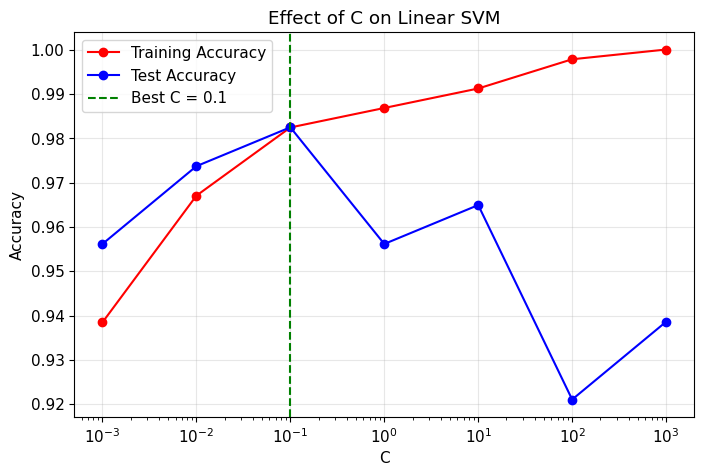


Support Vectors as C increases:
C = 0.001   → 218 support vectors
C = 0.01    → 105 support vectors
C = 0.1     → 53 support vectors
C = 1       → 36 support vectors
C = 10      → 30 support vectors
C = 100     → 25 support vectors
C = 1000    → 25 support vectors


In [9]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 8: C in Action on Real Data ──────────────────────────────────────

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

training_scores = []
test_scores = []
support_counts = []


# 1 & 2. Train Linear SVM for each C
for C in C_values:

    clf_c = SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)

    # Training accuracy
    train_acc = clf_c.score(X_tr_s, y_tr)

    # Test accuracy
    test_acc = clf_c.score(X_te_s, y_te)

    # Number of support vectors
    n_support = len(clf_c.support_)

    training_scores.append(train_acc)
    test_scores.append(test_acc)
    support_counts.append(n_support)


# 3. Create results table
task8_results = pd.DataFrame({
    'C': C_values,
    'Training Accuracy': training_scores,
    'Test Accuracy': test_scores,
    'Support Vectors': support_counts
})

print("Task 8 Results:\n")
print(task8_results.to_string(index=False))


# Find best C based on TEST accuracy
best_index = np.argmax(test_scores)

best_C = C_values[best_index]
best_test_accuracy = test_scores[best_index]

print("\nBest C:", best_C)
print(f"Best Test Accuracy: {best_test_accuracy:.2%}")


# 4. Plot Training vs Test Accuracy
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(
    C_values,
    training_scores,
    marker='o',
    color='red',
    label='Training Accuracy'
)

ax.semilogx(
    C_values,
    test_scores,
    marker='o',
    color='blue',
    label='Test Accuracy'
)


# 5. Vertical line showing best C
ax.axvline(
    best_C,
    color='green',
    linestyle='--',
    label=f'Best C = {best_C}'
)

ax.set_xlabel('C')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of C on Linear SVM')
ax.legend()
ax.grid(alpha=0.3)

plt.show()


# 6. Show how support vectors change with C
print("\nSupport Vectors as C increases:")

for C, n_sv in zip(C_values, support_counts):
    print(f"C = {C:<7} → {n_sv} support vectors")

**💬 Think About It:**

*At what C does training accuracy reach about 100%?*  
*At what C is the test accuracy highest? Is it the same C that gives the best training accuracy?*  
*What happens to the number of support vectors as C increases? Is that the same pattern you saw on the salary data?*

<details><summary>💡 Reveal Solution</summary>

```python
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs, n_svs = [], [], []
print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}  {"Num SVs":>8}')
print('-' * 45)
for C in C_values:
    clf_c = SVC(kernel='linear', C=C).fit(X_tr_s, y_tr)
    tr = clf_c.score(X_tr_s, y_tr); te = clf_c.score(X_te_s, y_te); sv_n = len(clf_c.support_)
    tr_accs.append(tr); te_accs.append(te); n_svs.append(sv_n)
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {sv_n:>8}')
best_C = C_values[int(np.argmax(te_accs))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(C_values, tr_accs, 'o-', color='#E63946', label='Training accuracy')
axes[0].semilogx(C_values, te_accs, 's-', color='#457B9D', label='Test accuracy')
axes[0].axvline(best_C, color='green', lw=2, ls='--', label=f'Best C = {best_C}')
axes[0].set_xlabel('C  (log scale)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('C vs Accuracy', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].semilogx(C_values, n_svs, 'D-', color='#F4A261')
axes[1].set_xlabel('C  (log scale)'); axes[1].set_ylabel('Number of support vectors')
axes[1].set_title('Larger C  →  fewer support vectors', fontweight='bold'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'\nBest C = {best_C}  →  Test accuracy = {max(te_accs):.4f}')
print('Note: with only 114 test patients, one patient = 0.9 points. In real projects choose C with cross-validation, not the test set.')
```
</details>

---
## ✏️ Task 9 — The Confusion Matrix: Not All Mistakes Are Equal  ⭐ *Bonus*

### Background
Accuracy hides the **type** of mistake. In cancer diagnosis:

| The model said... | Reality | Type | Consequence |
|---|---|---|---|
| Benign | Actually Malignant | **False Negative** | 🚨 Patient goes home — cancer untreated! |
| Malignant | Actually Benign | **False Positive** | 😟 Extra tests — stressful but safe |

A **False Negative** is far more dangerous. So: does the choice of C change the number of dangerous mistakes? (Next week's lecture on model evaluation goes much deeper.)

### Steps
1. Train linear SVMs with `C = 0.01, 1, 100` on the scaled cancer data
2. For each, plot a confusion matrix (3 subplots side by side)
3. Print the number of False Negatives for each C
4. Does the C with the best accuracy also have the fewest dangerous mistakes?

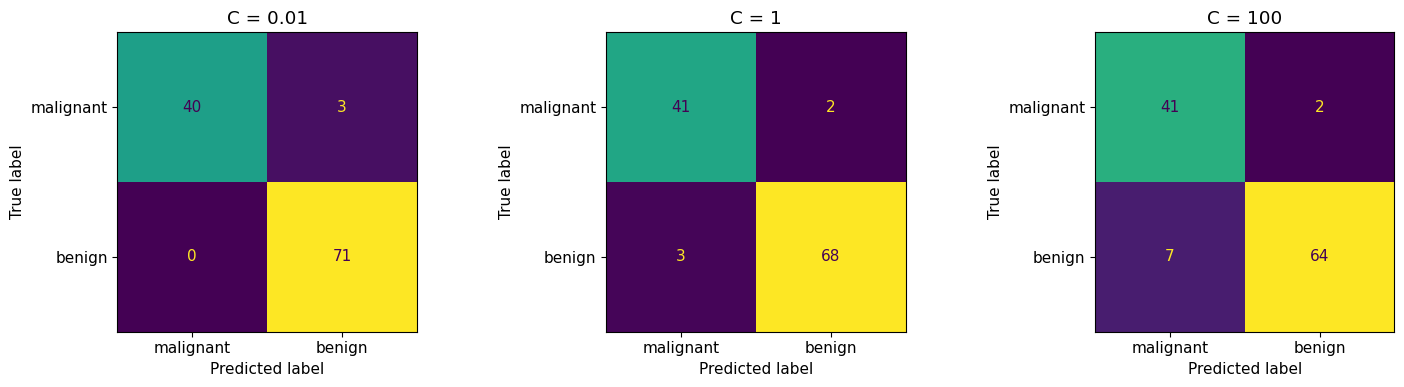


Results:
     C  Accuracy  False Negatives
  0.01  0.973684                3
  1.00  0.956140                2
100.00  0.921053                2

Best accuracy:
C = 0.01
Accuracy = 97.37%

Fewest False Negatives:
C = [1.0, 100.0]
False Negatives = 2


In [10]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 9: Confusion Matrix — Not All Mistakes Are Equal ─────────────────

C_values = [0.01, 1, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = []

for ax, C in zip(axes, C_values):

    # 1. Train Linear SVM
    clf_c = SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)

    # Predictions
    y_pred = clf_c.predict(X_te_s)

    # Accuracy
    accuracy = clf_c.score(X_te_s, y_te)

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)

    # sklearn cancer labels:
    # 0 = Malignant
    # 1 = Benign
    #
    # Dangerous mistake:
    # Actual Malignant (0), Predicted Benign (1)
    false_negatives = cm[0, 1]

    results.append({
        'C': C,
        'Accuracy': accuracy,
        'False Negatives': false_negatives
    })

    # 2. Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=cancer.target_names
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(f'C = {C}')


plt.tight_layout()
plt.show()


# 3. Print results
results_task9 = pd.DataFrame(results)

print("\nResults:")
print(results_task9.to_string(index=False))


# 4. Find best accuracy
best_accuracy_index = results_task9['Accuracy'].idxmax()

best_C = results_task9.loc[best_accuracy_index, 'C']
best_accuracy = results_task9.loc[best_accuracy_index, 'Accuracy']

# Find fewest dangerous mistakes
min_fn = results_task9['False Negatives'].min()

best_fn_C = results_task9[
    results_task9['False Negatives'] == min_fn
]['C'].tolist()

print("\nBest accuracy:")
print(f"C = {best_C}")
print(f"Accuracy = {best_accuracy:.2%}")

print("\nFewest False Negatives:")
print("C =", best_fn_C)
print("False Negatives =", min_fn)

**💬 Think About It:**

*Which C gives the fewest missed cancers?*  
*Is the C with the best overall accuracy also the safest for the patient?*  
*What does this tell you about choosing the right measure for a real-world problem?*

<details><summary>💡 Reveal Solution</summary>

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f'{"C":>6}  {"Accuracy":>10}  {"False Negatives (missed cancer!)":>32}')
print('-' * 55)
for ax, C in zip(axes, [0.01, 1, 100]):
    clf_c = SVC(kernel='linear', C=C).fit(X_tr_s, y_tr)
    y_pred = clf_c.predict(X_te_s)
    acc = clf_c.score(X_te_s, y_te)
    fn = confusion_matrix(y_te, y_pred)[0, 1]       # actual malignant (0), predicted benign (1)
    print(f'{C:>6}  {acc:>10.4f}  {fn:>32}')
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=cancer.target_names, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  False Neg={fn}', fontweight='bold')
plt.suptitle('Breast Cancer: how C affects the type of mistake', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# 🌸 PART 3 — Iris Flowers (Bonus)
## "Can a machine tell flower species apart from petal measurements?"

Iris has 3 species and only 4 measurements. Using just **two** (petal length and petal width) lets us **draw** what each kernel learns.

---

---
## ✏️ Task 10 — Linear vs RBF vs Polynomial: Draw the Boundaries  ⭐ *Bonus*

### Background
Different kernels draw different boundaries (remember the three-kernels slide): linear = straight lines, RBF = smooth curves in any direction, polynomial = curves from feature combinations.

SVM handles **3 classes** automatically: it splits the problem into several yes/no questions behind the scenes, so the code is exactly the same as for two classes.

The real question: does extra bending actually help on this data?

### Steps
1. Use only petal length and petal width (`iris.data[:, 2:4]`). Split 70/30 with `random_state=0`, scale (fit on train only)
2. Train 3 models, all with `C = 1`: `kernel="linear"`, `kernel="rbf"`, `kernel="poly"`
3. For each, draw the decision regions (coloured background), the training points, and circle the support vectors in gold
4. Show training **and** test accuracy in each title and print a comparison table
5. Which kernel generalises best? Is the most complex boundary always the best?

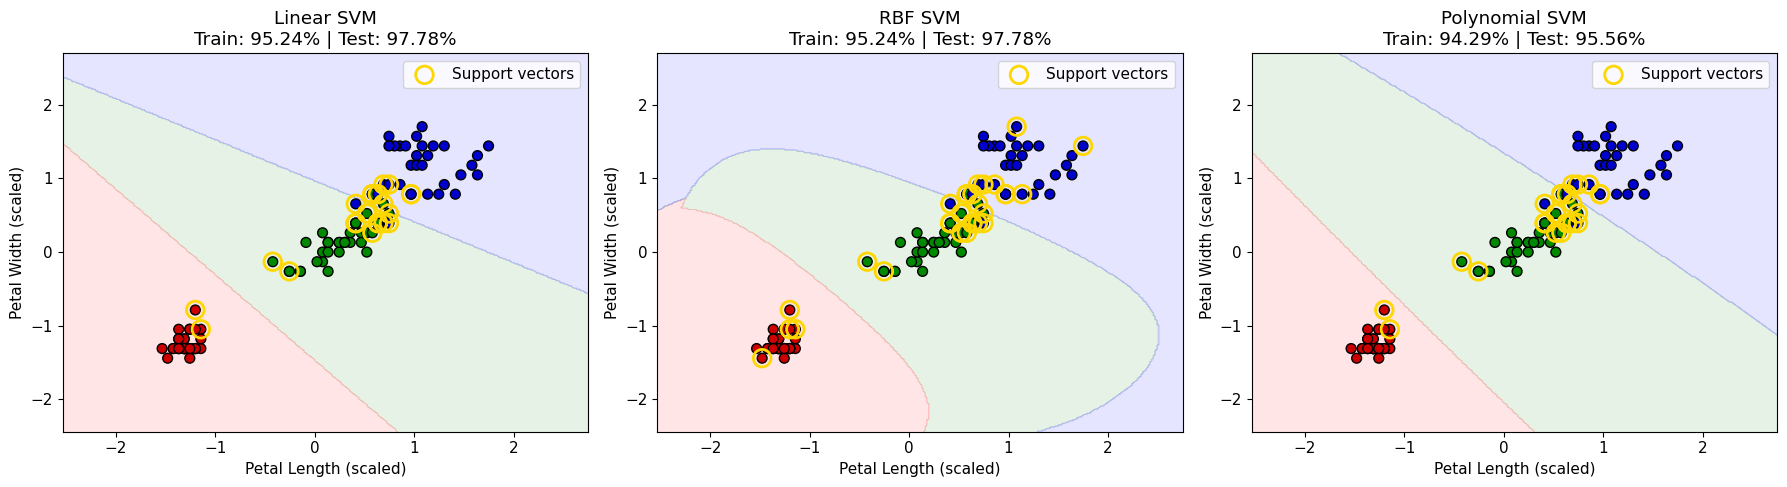


Kernel Comparison:
    Kernel  Training Accuracy  Test Accuracy  Support Vectors
    Linear           0.952381       0.977778               24
       RBF           0.952381       0.977778               31
Polynomial           0.942857       0.955556               26

Best generalising kernel: Linear
Best test accuracy: 97.78%


In [11]:
# ── Your code here ────────────────────────────────────────────────────────
# ── Task 10: Linear vs RBF vs Polynomial — Iris ────────────────────────────

# 1. Use only petal length and petal width
X_iris = iris.data[:, 2:4]
y_iris = iris.target

# 70/30 train-test split
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=0,
    stratify=y_iris
)

# Scale — fit ONLY on training data
scaler_i = StandardScaler()

X_tr_i_s = scaler_i.fit_transform(X_tr_i)
X_te_i_s = scaler_i.transform(X_te_i)


# 2. Define the three SVM models
models = {
    'Linear': SVC(kernel='linear', C=1),
    'RBF': SVC(kernel='rbf', C=1),
    'Polynomial': SVC(kernel='poly', C=1)
}


# Store results
results = []

# 3. Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for ax, (name, model) in zip(axes, models.items()):

    # Train model
    model.fit(X_tr_i_s, y_tr_i)

    # 4. Accuracy
    train_acc = model.score(X_tr_i_s, y_tr_i)
    test_acc = model.score(X_te_i_s, y_te_i)

    results.append({
        'Kernel': name,
        'Training Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Support Vectors': len(model.support_)
    })


    # ── Create decision-region grid ────────────────────────────────────────

    x_min = X_tr_i_s[:, 0].min() - 1
    x_max = X_tr_i_s[:, 0].max() + 1

    y_min = X_tr_i_s[:, 1].min() - 1
    y_max = X_tr_i_s[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)


    # Decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.25,
        cmap=ListedColormap(['#FF9999', '#99CC99', '#9999FF'])
    )


    # Training points
    scatter = ax.scatter(
        X_tr_i_s[:, 0],
        X_tr_i_s[:, 1],
        c=y_tr_i,
        cmap=ListedColormap(['#CC0000', '#008800', '#0000CC']),
        edgecolors='black',
        s=50
    )


    # Circle support vectors in gold
    ax.scatter(
        X_tr_i_s[model.support_, 0],
        X_tr_i_s[model.support_, 1],
        s=160,
        facecolors='none',
        edgecolors='gold',
        linewidths=2,
        label='Support vectors'
    )


    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')

    ax.set_title(
        f'{name} SVM\n'
        f'Train: {train_acc:.2%} | Test: {test_acc:.2%}'
    )

    ax.legend()


plt.tight_layout()
plt.show()


# ── 4. Print comparison table ──────────────────────────────────────────────

results_task10 = pd.DataFrame(results)

print("\nKernel Comparison:")
print(results_task10.to_string(index=False))


# ── 5. Find kernel with best test accuracy ─────────────────────────────────

best_index = results_task10['Test Accuracy'].idxmax()

best_kernel = results_task10.loc[best_index, 'Kernel']
best_test = results_task10.loc[best_index, 'Test Accuracy']

print("\nBest generalising kernel:", best_kernel)
print(f"Best test accuracy: {best_test:.2%}")

**💬 Think About It:**

*Which kernel gives the highest test accuracy?*  
*Do the classes really need curved boundaries here?*  
*Is a more complex kernel always better? Connect your answer to what you saw in Task 4.*

<details><summary>💡 Reveal Solution</summary>

```python
X_pet = iris.data[:, 2:4]
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_pet, iris.target, test_size=0.3, random_state=0)
sc = StandardScaler()
X_ptr_s = sc.fit_transform(X_ptr)
X_pte_s = sc.transform(X_pte)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for ax, k in zip(axes, ['linear', 'rbf', 'poly']):
    clf_k = SVC(kernel=k, C=1).fit(X_ptr_s, y_ptr)
    tr = clf_k.score(X_ptr_s, y_ptr); te = clf_k.score(X_pte_s, y_pte)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')
    x_min, x_max = X_ptr_s[:, 0].min() - 0.5, X_ptr_s[:, 0].max() + 0.5
    y_min, y_max = X_ptr_s[:, 1].min() - 0.5, X_ptr_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color, name in zip([0, 1, 2], ['#E63946', '#2A9D8F', '#457B9D'], iris.target_names):
        m = (y_ptr == cls)
        ax.scatter(X_ptr_s[m, 0], X_ptr_s[m, 1], c=color, edgecolors='k', s=40, label=name, zorder=3)
    sv = clf_k.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=180, facecolors='none', edgecolors='gold', lw=2, zorder=4)
    ax.set_title(f'{k.capitalize()} kernel\nTrain={tr:.2f}  Test={te:.2f}', fontweight='bold')
    ax.set_xlabel('Petal length (scaled)'); ax.set_ylabel('Petal width (scaled)'); ax.legend(fontsize=8)
plt.suptitle('Iris: comparing kernels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
## 📝 Final Reflection

*There are no right or wrong answers — just think it through and write your answers below.*

---

**Q1 — Support vectors:**  
In Task 2 only a few dots sat on the street edge, and in Task 7 a model trained on *only* the support vectors predicted like the full model. What does this tell you about how SVM "remembers" its training data compared with KNN, which keeps every dot?

**Q2 — The C parameter:**  
A classmate says: "I always set C = 1000 so the model works hard and makes fewer mistakes." Using Task 3 (the odd person) and Task 8, what would you say to them?

**Q3 — Kernels:**  
In Task 4, RBF scored 100% on the 20 people it studied, yet plain linear (with a larger C) did better on left-out people. Why can the simplest kernel win?

**Q4 — Scaling:**  
In Task 6, scaling helped the RBF model but barely changed the linear one. Why do we fit the scaler on the training data only, and not on the whole dataset?

**Q5 — Overfitting everywhere:**  
Compare K = 1 in KNN (Lecture 17), a very large C (Task 3) and a very large gamma (Task 5). What do all three have in common?

**Your answers:**

Q1:

Q2:

Q3:

Q4:

Q5:

---
## 🗺️ What You Covered

```
💼 Salary data  (Tasks 1–5)   — the same 20 people as the slides
   Task 1  →  Label the data and draw it
   Task 2  →  Find the hyperplane, the margin and the support vectors (score = 2×exp + 2×certs − 13)
   Task 3  →  Hard margin breaks with one odd person; the C dial widens or thins the street
   Task 4  →  Linear vs polynomial vs RBF, judged on left-out people (C matters as much as the kernel)
   Task 5  →  gamma: how an RBF model starts to memorise

🏥 Breast Cancer  (Tasks 6–8, bonus 9)
   Task 6  →  Scaling matters (for RBF) — with numbers
   Task 7  →  Prove that only support vectors decide the boundary
   Task 8  →  C on real data
   Task 9  →  Confusion matrix: not all mistakes are equal  ⭐

🌸 Iris  (bonus 10)
   Task 10 →  Draw what each kernel learns  ⭐
```

---
*🎓 Well done! Next week: how to compare models fairly (model evaluation).*